# Energy Consumption Time Series Forecasting

Objective:
Forecast short-term household energy usage using historical time-based patterns.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 809.4 kB/s eta 0:00:15
   - -------------------------------------- 0.5/12.1 MB 809.4 kB/s eta 0:00:15
   -- ------------------------------------- 0.8/12.1 MB 754.9 kB/s eta 0:00:15
   -- ------------------------------------- 0.8/12.1 MB 754.9 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/12.1 MB 742.2 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/12.1 MB 742.2 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/12.1 MB 742.2 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/12.1 MB 742.2 kB/s eta 0:00:15
   ----- ---------------------------------- 1.6/12.1 MB 661.4 kB/s eta 0:00:16
   ----- ---------------------------------- 1.6/12.1 MB 661.4 kB/s eta 0:00:16



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 700.1 kB/s eta 0:00:14
   -- ------------------------------------- 0.5/9.9 MB 700.1 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.9 MB 704.6 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.9 MB 704.6 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.9 MB 710.2 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.9 MB 710.2 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.9 MB 692.9 kB/s eta 0:00:13
   ------ ------------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

In [2]:
#Load the dataset
df = pd.read_csv(
    "household_power_consumption.csv",
    na_values='?',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True
)

C:\Users\hinaa\AppData\Local\Temp\ipykernel_1740\3642069928.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\hinaa\AppData\Local\Temp\ipykernel_1740\3642069928.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\hinaa\AppData\Local\Temp\ipykernel_1740\3642069928.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [4]:
#Data Cleaning
#Convert power column to numeric:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)


In [5]:
# REMOVE INVALID VALUES
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(subset=['Global_active_power'], inplace=True)

In [6]:
#Set Datetime Index
df.set_index('Datetime', inplace=True)

In [7]:
# RESAMPLE
hourly_df = (
    df['Global_active_power']
    .resample('h')
    .mean()
    .ffill()
)

daily_df = df['Global_active_power'].resample('D').mean()  #Daily aggregation

In [8]:
#Feature Engineering
#Creating time-based features:
hourly = hourly_df.to_frame()
hourly['hour'] = hourly.index.hour
hourly['dayofweek'] = hourly.index.dayofweek
hourly['month'] = hourly.index.month
hourly['is_weekend'] = hourly['dayofweek'].isin([5,6]).astype(int)

In [9]:
#Lag features:
hourly['lag_1'] = (
    hourly['Global_active_power'].shift(1)
)

hourly['lag_24'] = (
    hourly['Global_active_power'].shift(24)
)

In [10]:
#statistics:
hourly['rolling_mean_24'] = (
    hourly['Global_active_power']
    .rolling(24)
    .mean()
)

In [11]:
# REMOVE NANs AGAIN
hourly.replace([np.inf, -np.inf], np.nan, inplace=True)

hourly.dropna(inplace=True)

In [12]:
# ENSURE FLOAT TYPE
hourly = hourly.astype(float)

In [13]:
# FEATURES
features = [
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'lag_1',
    'lag_24',
    'rolling_mean_24'
]

### Train/Test Split

In [14]:
train_size = int(len(hourly) * 0.8)

train = hourly.iloc[:train_size]
test = hourly.iloc[train_size:]

X_train = train[features]
X_test = test[features]

##### Target variable

In [15]:
y_train = train['Global_active_power']
y_test = test['Global_active_power']

In [16]:
# FINAL CHECK
print(y_train.isnull().sum())
print(np.isinf(y_train).sum())

0
0


### Model Training

#### ARIMA Model

ARIMA formula: ARIMA(p,d,q)

In [17]:
arima_model = ARIMA(y_train, order=(5,1,2))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(
    steps=len(test)
)

C:\Users\hinaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
#Evaluating the model:
arima_mae = mean_absolute_error(y_test, arima_forecast)
arima_rmse = np.sqrt(
    mean_squared_error(y_test, arima_forecast)
)
print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 0.6844847586585183
ARIMA RMSE: 0.9066128120003377


#### Prophet Model

In [19]:
prophet_df = hourly.reset_index()[[
    'Datetime',
    'Global_active_power'
]]

prophet_df.columns = ['ds', 'y']

In [20]:
#Train/test split:

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [21]:
#Train model:

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)
model.fit(train_prophet)

22:45:50 - cmdstanpy - INFO - Chain [1] start processing
22:45:53 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
#Future dataframe:

future = model.make_future_dataframe(
    periods=len(test_prophet),
    freq='H'
)

forecast = model.predict(future)

C:\Users\hinaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [23]:
#Extract predictions:
prophet_forecast = forecast['yhat'].iloc[-len(test_prophet):].values

In [24]:
#Evaluating the model:

prophet_mae = mean_absolute_error(
    test_prophet['y'],
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        prophet_forecast
    )
)

#### XGBoost Model

In [25]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# PREDICTION
xgb_forecast = xgb_model.predict(X_test)

In [26]:
# EVALUATION
mae = mean_absolute_error(y_test, xgb_forecast)

rmse = np.sqrt(
    mean_squared_error(y_test, xgb_forecast)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.3186555221325773
RMSE: 0.49179350282944295


### Compare Models

In [28]:
#Create comparison table:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [
        arima_mae,
        prophet_mae,
        mae
    ],
    'RMSE': [
        arima_rmse,
        prophet_rmse,
        rmse
    ]
})

print(results)

     Model       MAE      RMSE
0    ARIMA  0.684485  0.906613
1  Prophet  0.707265  0.942075
2  XGBoost  0.318656  0.491794


#### Visualization

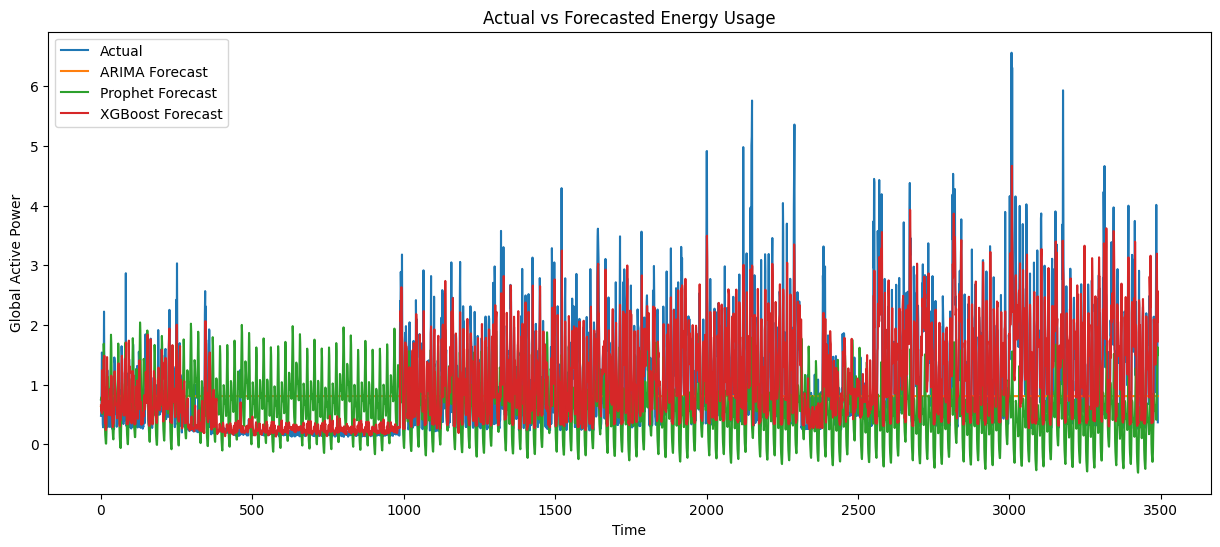

In [29]:
#Actual vs Forecast
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    arima_forecast.values,
    label='ARIMA Forecast'
)

plt.plot(
    prophet_forecast,
    label='Prophet Forecast'
)

plt.plot(
    xgb_forecast,
    label='XGBoost Forecast'
)

plt.legend()
plt.title("Actual vs Forecasted Energy Usage")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.show()

The graph compares:<br>
Blue → Actual energy consumption<br>
Orange → ARIMA forecast<br>
Green → Prophet forecast<br>
Red → XGBoost forecast<br>
<br>
The comparison demonstrates that XGBoost achieved superior forecasting performance compared to ARIMA and Prophet. XGBoost closely tracked the actual household energy consumption and captured short-term fluctuations effectively. Prophet successfully modeled seasonality but underestimated sudden spikes, while ARIMA captured the general trend but failed to represent nonlinear volatility. These findings indicate that machine learning approaches combined with temporal feature engineering are more effective for short-term household energy forecasting.<br>

The graph also shows:<br>
forecasting becomes harder during high-consumption periods<br>
all models struggle with extreme spikes<br>
energy usage contains stochastic behavior<br>